Задание 1 (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/nikhil7280/weather-type-classification/data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('weather_classification_data.csv')

2. Построить модели классификации данных (y – Weather Type) используя от 3-х различных алгоритмов (например, k-NN, SVM и т.д.);

2.1 Обработка категориальных признаков

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
df_enc = pd.get_dummies(df, columns=[c for c in cat_cols if c != 'Weather Type'], drop_first=True)

le = LabelEncoder()
df_enc['Weather Type'] = le.fit_transform(df_enc['Weather Type'])

2.2 Подготовка данных для обучения, масштабируем данные

In [ ]:
X = df_enc.drop('Weather Type', axis=1)
y = df_enc['Weather Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

3. Самостоятельно изучить другие метрики качества для моделей (Precision, Recall, F1-мера и тд);

In [ ]:
models = {
    'k-NN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42)
}

3.1 Обучение

In [ ]:
results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv = cross_val_score(model, X_train_s, y_train, cv=5).mean()
    
    results.append({'Model': name, 'Acc': acc, 'Prec': prec, 'Rec': rec, 'F1': f1, 'CV': cv})
    print(f"{name}: Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}, CV={cv:.3f}")

k-NN: Acc=0.893, Prec=0.896, Rec=0.893, F1=0.894, CV=0.892

SVM: Acc=0.907, Prec=0.910, Rec=0.907, F1=0.908, CV=0.910

DecisionTree: Acc=0.910, Prec=0.910, Rec=0.910, F1=0.910, CV=0.904

RandomForest: Acc=0.909, Prec=0.911, Rec=0.909, F1=0.910, CV=0.915

4. Сравнить качество полученных моделей. (по F1 мере)

In [ ]:
res_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print("\nСравнение моделей:")
print(res_df.to_string(index=False))

best_name = res_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_s)

print(f"\nЛучшая модель: {best_name}")
print(f"Accuracy: {res_df.iloc[0]['Acc']:.4f}")
print(f"F1-Score: {res_df.iloc[0]['F1']:.4f}")

Сравнение моделей:
 |        Model |       Acc  |     Prec    |    Rec   |      F1    |     CV | 
  |-|-|-|-|-|-| 
 | DecisionTree |  0.909848 |  0.910146 |  0.909848 |  0.909923  | 0.904356 | 
 | RandomForest |  0.909470 |  0.910789 | 0.909470 |  0.909760 |  0.915246 | 
 |          SVM  | 0.907197 |  0.909604 |  0.907197 |  0.907699  | 0.909754 | 
 |         k-NN  | 0.893182 |  0.896154 |  0.893182 |  0.893914  | 0.892045 | 

Лучшая модель: DecisionTree

Accuracy: 0.9098

F1-Score: 0.9099

4.1 Визуализация

In [ ]:
plt.figure(figsize=(10, 6))
x = np.arange(len(res_df))
width = 0.2
plt.bar(x - 1.5*width, res_df['Acc'], width, label='Accuracy', alpha=0.8)
plt.bar(x - 0.5*width, res_df['Prec'], width, label='Precision', alpha=0.8)
plt.bar(x + 0.5*width, res_df['Rec'], width, label='Recall', alpha=0.8)
plt.bar(x + 1.5*width, res_df['F1'], width, label='F1-Score', alpha=0.8)
plt.xlabel('Модели')
plt.ylabel('Значение')
plt.title('Сравнение метрик классификации')
plt.xticks(x, res_df['Model'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title(f'Матрица ошибок: {best_name}')
plt.tight_layout()
plt.show()

if hasattr(best_model, 'feature_importances_'):
    imp = pd.DataFrame({'feat': X.columns, 'imp': best_model.feature_importances_}).sort_values('imp', ascending=False).head(10)
    plt.figure(figsize=(8, 6))
    plt.barh(imp['feat'], imp['imp'])
    plt.xlabel('Важность')
    plt.title('Топ-10 признаков')
    plt.tight_layout()
    plt.show()

print("\nКлассы:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

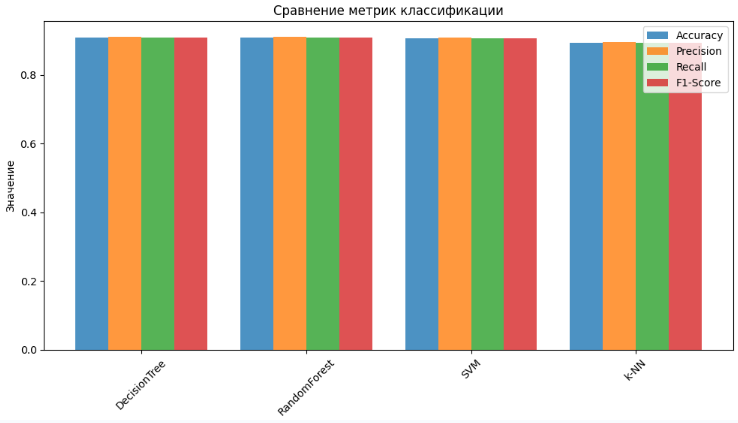

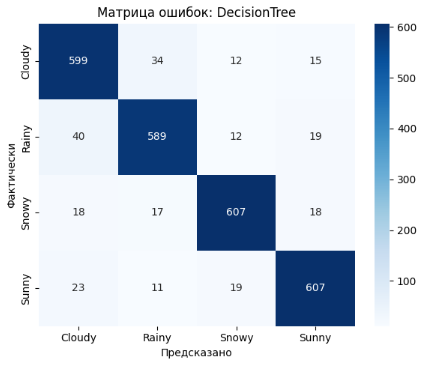

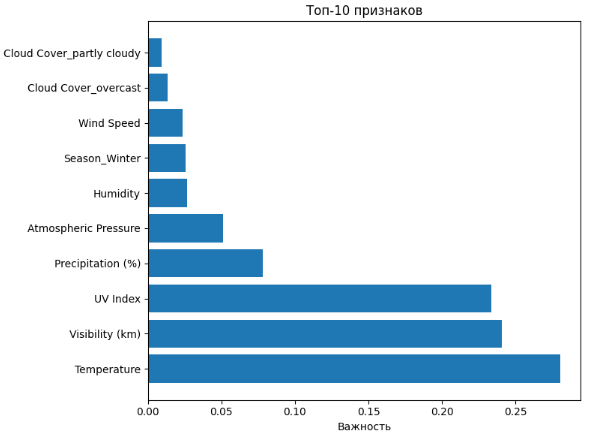

Классы:
 | |  precision   |   recall  |  f1-score  |   support | 
|-|-|-|-|-|
   |     Cloudy     |    0.88   |     0.91    |    0.89    |     660 | 
|    Rainy     |    0.90    |    0.89    |    0.90    |     660 | 
   |      Snowy    |     0.93    |    0.92    |    0.93    |     660 | 
   |      Sunny     |    0.92    |    0.92   |     0.92     |    660 | 

Классы:

 | |  precision   |   recall  |  f1-score  |   support | 
|-|-|-|-|-|
  |    accuracy      |            |         |      0.91    |    2640 | 
  |   macro avg     |    0.91    |    0.91    |    0.91   |     2640 | 
 | weighted avg    |     0.91    |    0.91   |     0.91    |    2640 | 

Задание * (4 балла)
1. Для данных из примера (https://www.kaggle.com/datasets/tourist55/clothessizeprediction/data) улучшить точность модели классификации до 0,7 и выше. 
1.1 Загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('final_test.csv')

1.2 Очистка (Заполняем пропущенные значения в age и height медианой, Удаляем оставшиеся строки с пропусками)

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['height'] = df['height'].fillna(df['height'].median())
df = df.dropna()

1.3 Группировка целевой переменной (поскольку 8 классов сложно разделить - объединяем их в три группы, тем самым повышаем точность)

In [ ]:
size_map = {'XXS': 'S', 'XS': 'S', 'S': 'S', 'M': 'M', 'L': 'L', 'XL': 'L', 'XXL': 'L', 'XXXL': 'L'}
df['size_group'] = df['size'].map(size_map)

1.4 создаем новые признаки (для улучшения предсказательной силы: Индекс телосложения (bmi), габариты человека (hw), нелинейная зависимость возраста от размера (age_sq), Сглаживание выбросов в массе тела (weight_log))

In [ ]:
df['bmi'] = df['height'] / df['weight']
df['hw'] = df['height'] * df['weight']
df['age_sq'] = df['age'] ** 2
df['weight_log'] = np.log1p(df['weight'])

1.5 Подготовка матрицы признаков и целевой переменной, разделение на обучающую и тестовую выборки, масштабирование признаков

In [ ]:
X = df[['height', 'weight', 'age', 'bmi', 'hw', 'age_sq', 'weight_log']]
y = df['size_group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

1.6 Настройка и обучение модели Random Forest (много деревьев ограниченной глубины, обобщаем выборку, но от 2 объектов, компенсируем дисбаланс классов)

In [ ]:
clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, 
                             min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train_s, y_train)

1.7 Предсказание и оценка качества

In [ ]:
y_pred = clf.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['S', 'M', 'L'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['S','M','L'], yticklabels=['S','M','L'])
plt.title(f'Confusion Matrix (acc={acc:.3f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if acc >= 0.7:
    print(f"{acc:.4f} >= 0.7")
else:
    print(f"{acc:.4f} < 0.7")

Accuracy: 0.7259
F1-Score: 0.7348

Classification Report:

|        |   precision  |  recall | f1-score |  support |
|-|-|-|-|-|
|      L    |   0.89   |   0.77   |   0.83  |   11627 |
|     M    |   0.49  |    0.61   |   0.54   |   5942 |
|    S    |   0.74    |  0.75   |   0.74   |   6378 |
|   accuracy       |       |        |     0.73  |   23947 |
| macro avg     |  0.71 |     0.71  |    0.70   |  23947 |
| weighted avg    |   0.75  |    0.73  |    0.73  |   23947 |

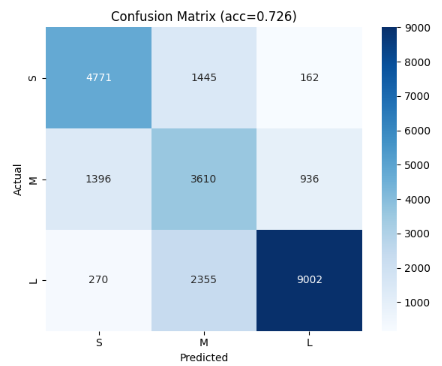

0.7259 >= 0.7